In [2]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib

In [3]:
url = "https://api.frankfurter.app/2024-01-01..2026-08-30?from=EUR&to=USD"
response = requests.get(url)
data = response.json()
data

{'amount': 1.0,
 'base': 'EUR',
 'start_date': '2023-12-29',
 'end_date': '2026-08-28',
 'rates': {'2023-12-29': {'USD': 1.105},
  '2024-01-02': {'USD': 1.0956},
  '2024-01-03': {'USD': 1.0919},
  '2024-01-04': {'USD': 1.0953},
  '2024-01-05': {'USD': 1.0921},
  '2024-01-08': {'USD': 1.0946},
  '2024-01-09': {'USD': 1.094},
  '2024-01-10': {'USD': 1.0946},
  '2024-01-11': {'USD': 1.0987},
  '2024-01-12': {'USD': 1.0942},
  '2024-01-15': {'USD': 1.0945},
  '2024-01-16': {'USD': 1.0882},
  '2024-01-17': {'USD': 1.0877},
  '2024-01-18': {'USD': 1.0875},
  '2024-01-19': {'USD': 1.0887},
  '2024-01-22': {'USD': 1.089},
  '2024-01-23': {'USD': 1.0872},
  '2024-01-24': {'USD': 1.0905},
  '2024-01-25': {'USD': 1.0893},
  '2024-01-26': {'USD': 1.0871},
  '2024-01-29': {'USD': 1.0823},
  '2024-01-30': {'USD': 1.0846},
  '2024-01-31': {'USD': 1.0837},
  '2024-02-01': {'USD': 1.0814},
  '2024-02-02': {'USD': 1.0883},
  '2024-02-05': {'USD': 1.0746},
  '2024-02-06': {'USD': 1.0743},
  '2024-02-07':

In [4]:
rates = data["rates"]
df = pd.DataFrame([
    {"Date": date,"Rate": values["USD"]}
    for date, values in rates.items()
])
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Rate
0,2023-12-29,1.1050
1,2024-01-02,1.0956
2,2024-01-03,1.0919
3,2024-01-04,1.0953
4,2024-01-05,1.0921


In [5]:
# Transfer DataFrame to a CSV file
df.to_csv("output.csv", index=False)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    680 non-null    datetime64[us]
 1   Rate    680 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 10.8 KB


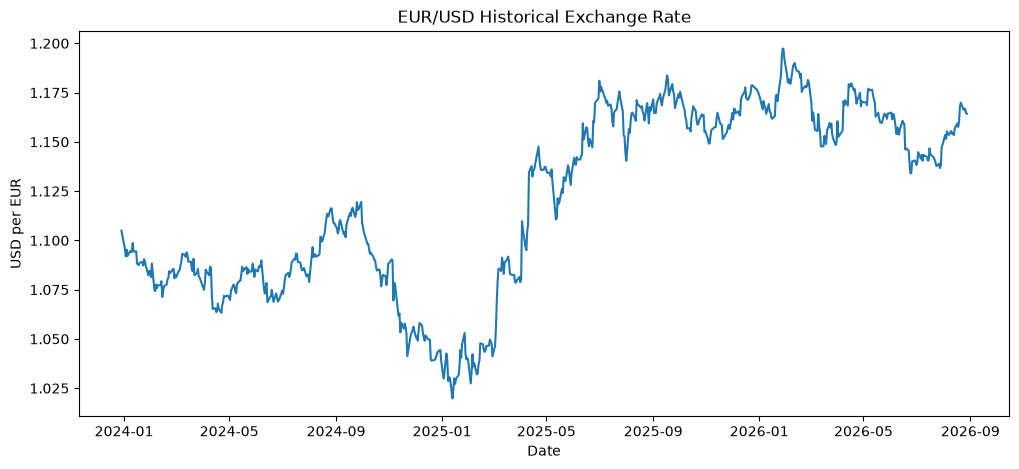

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Rate"])
plt.title("EUR/USD Historical Exchange Rate")
plt.xlabel("Date")
plt.ylabel("USD per EUR")
plt.show()

In [8]:
df["lag_1"] = df["Rate"].shift(1)
df["lag_7"] = df["Rate"].shift(7)
df["ma_7"] = df["Rate"].shift(1).rolling(window=7).mean()
df["ma_30"] = df["Rate"].shift(1).rolling(window=30).mean()
df.head(10)

,Date,Rate,lag_1,lag_7,ma_7,ma_30
0,2023-12-29,1.1050,NaN,NaN,NaN,NaN
1,2024-01-02,1.0956,1.1050,NaN,NaN,NaN
2,2024-01-03,1.0919,1.0956,NaN,NaN,NaN
3,2024-01-04,1.0953,1.0919,NaN,NaN,NaN
4,2024-01-05,1.0921,1.0953,NaN,NaN,NaN
5,2024-01-08,1.0946,1.0921,NaN,NaN,NaN
6,2024-01-09,1.0940,1.0946,NaN,NaN,NaN
7,2024-01-10,1.0946,1.0940,1.1050,1.095500,NaN
8,2024-01-11,1.0987,1.0946,1.0956,1.094014,NaN
9,2024-01-12,1.0942,1.0987,1.0919,1.094457,NaN


In [9]:
df = df.dropna().reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    650 non-null    datetime64[us]
 1   Rate    650 non-null    float64       
 2   lag_1   650 non-null    float64       
 3   lag_7   650 non-null    float64       
 4   ma_7    650 non-null    float64       
 5   ma_30   650 non-null    float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 30.6 KB


In [10]:
features = ["lag_1", "lag_7", "ma_7", "ma_30"]
X = df[features]
y = df["Rate"]
X.head()

,lag_1,lag_7,ma_7,ma_30
0,1.0772,1.0814,1.078457,1.088183
1,1.0773,1.0883,1.077871,1.087260
2,1.0793,1.0746,1.076586,1.086717
3,1.0713,1.0743,1.076114,1.086030
4,1.0743,1.0776,1.076114,1.085330


In [11]:
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]


train_dates = df["Date"].iloc[:train_size]
test_dates = df["Date"].iloc[train_size:]


print("Training data:", len(X_train))
print("Testing data:", len(X_test))

print("\nTraining period:")
print(train_dates.min(), "to", train_dates.max())

print("\nTesting period:")
print(test_dates.min(), "to", test_dates.max())

Training data: 520
Testing data: 130

Training period:
2024-02-12 00:00:00 to 2026-02-24 00:00:00

Testing period:
2026-02-25 00:00:00 to 2026-08-28 00:00:00


-----------------------------------------------
-----------------------------------------------

In [12]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [13]:
mae_lr = mean_absolute_error(y_test, lr_predictions)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, lr_predictions)
)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE: {mae_lr:.6f}")
print(f"RMSE: {rmse_lr:.6f}")

Linear Regression Results
-------------------------
MAE: 0.003019
RMSE: 0.004181


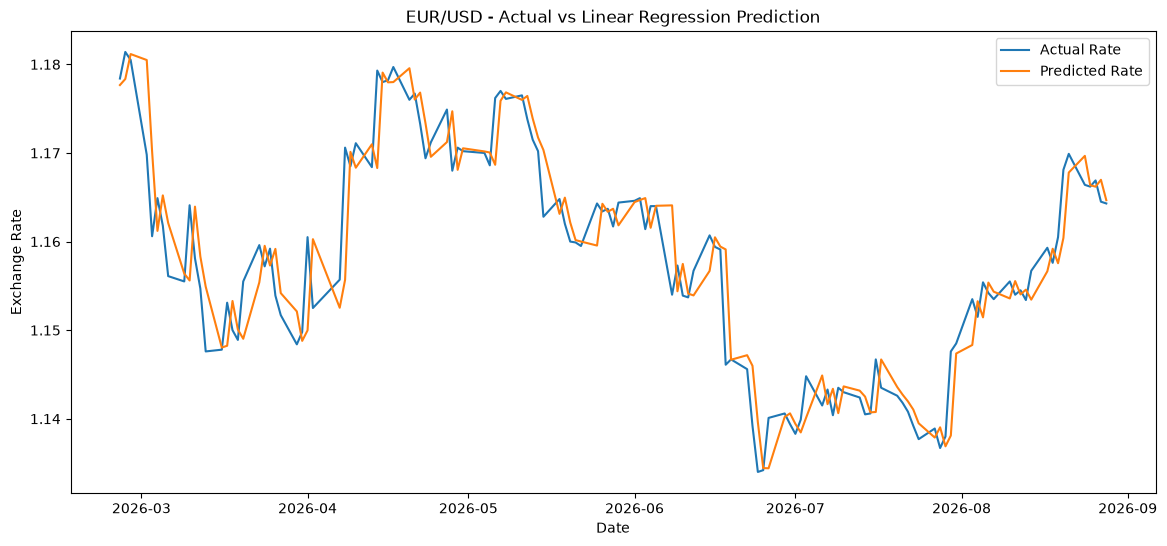

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(
    test_dates,
    y_test,
    label="Actual Rate"
)

plt.plot(
    test_dates,
    lr_predictions,
    label="Predicted Rate"
)

plt.title("EUR/USD - Actual vs Linear Regression Prediction")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.show()

In [15]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [16]:
mae_rf = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

print("Random Forest Results")
print("-------------------------")
print(f"MAE: {mae_rf:.6f}")
print(f"RMSE: {rmse_rf:.6f}")

Random Forest Results
-------------------------
MAE: 0.004978
RMSE: 0.006599


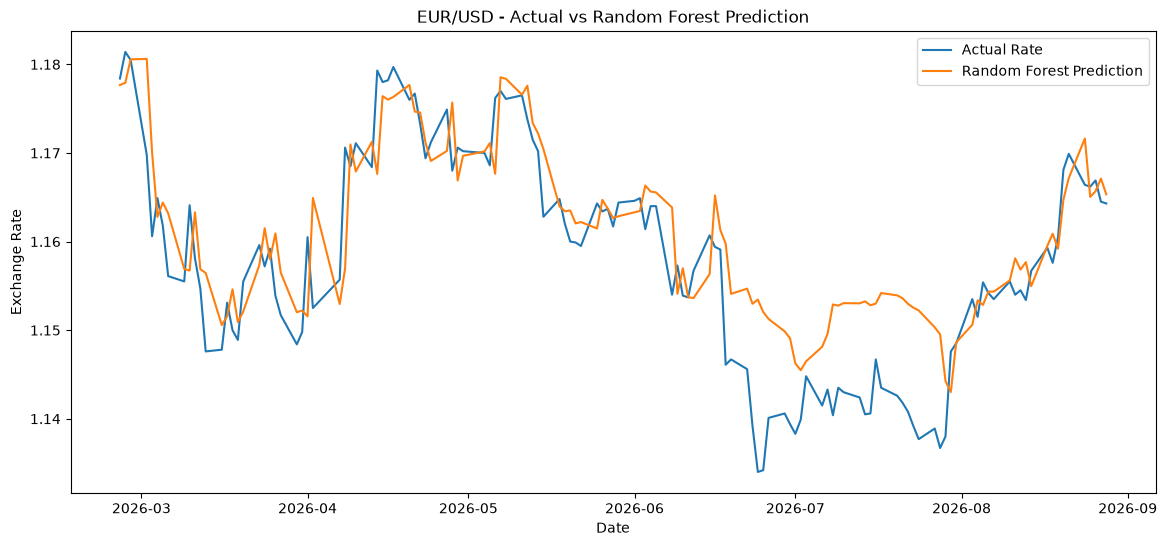

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test,
    label="Actual Rate"
)

plt.plot(
    test_dates,
    rf_predictions,
    label="Random Forest Prediction"
)

plt.title("EUR/USD - Actual vs Random Forest Prediction")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.show()

In [18]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(X_test)

In [19]:
mae_xgb = mean_absolute_error(
    y_test,
    xgb_predictions
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

print("XGBoost Results")
print("----------------")
print(f"MAE: {mae_xgb:.6f}")
print(f"RMSE: {rmse_xgb:.6f}")

XGBoost Results
----------------
MAE: 0.004599
RMSE: 0.005936


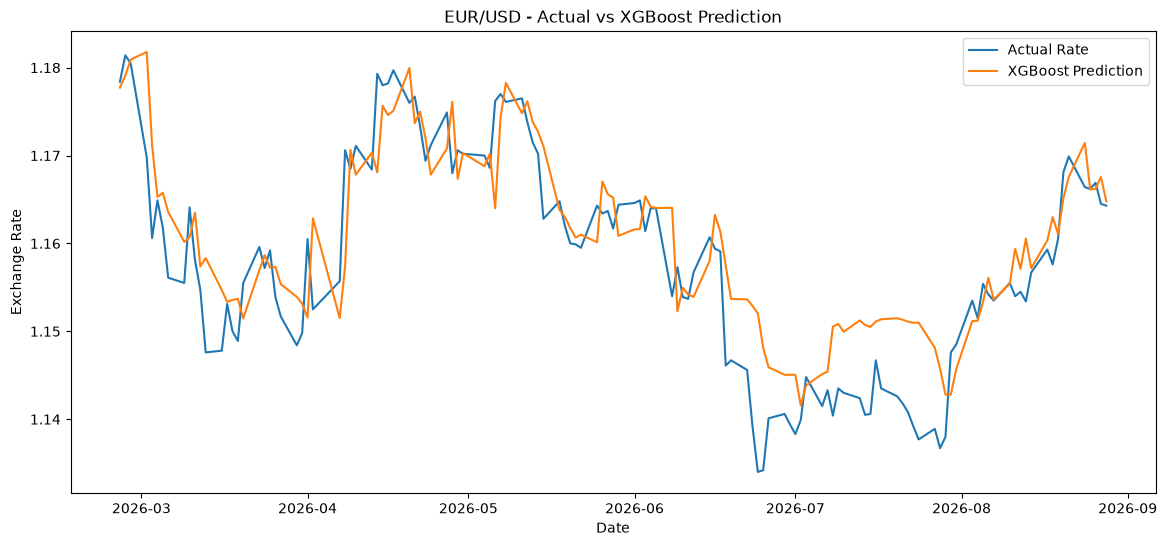

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test,
    label="Actual Rate"
)

plt.plot(
    test_dates,
    xgb_predictions,
    label="XGBoost Prediction"
)

plt.title("EUR/USD - Actual vs XGBoost Prediction")

plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()

plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ]
})

results = results.sort_values("MAE").reset_index(drop=True)

results

,Model,MAE,RMSE
0,Linear Regression,0.003019,0.004181
1,XGBoost,0.004599,0.005936
2,Random Forest,0.004981,0.006601


,Model,MAE,RMSE
0,Linear Regression,0.003019,0.004181
1,XGBoost,0.004599,0.005936
2,Random Forest,0.004978,0.006599


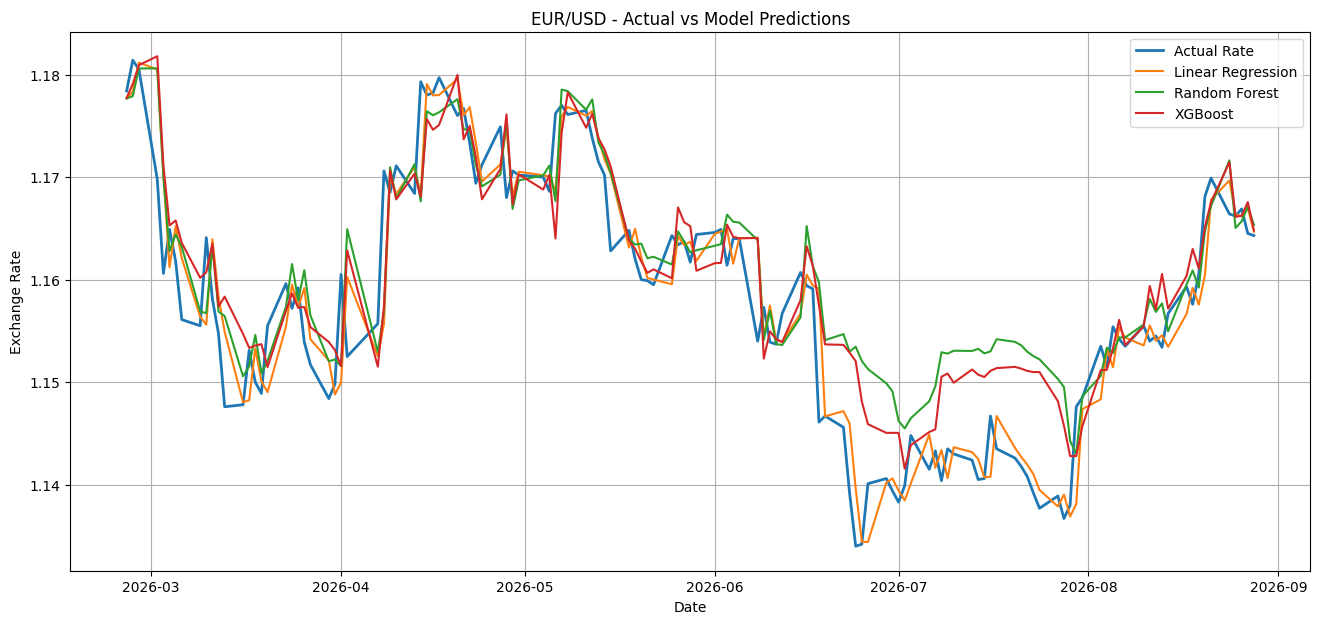

In [ ]:
plt.figure(figsize=(16, 7))

plt.plot(
    test_dates,
    y_test,
    label="Actual Rate",
    linewidth=2
)

plt.plot(
    test_dates,
    lr_predictions,
    label="Linear Regression"
)

plt.plot(
    test_dates,
    rf_predictions,
    label="Random Forest"
)

plt.plot(
    test_dates,
    xgb_predictions,
    label="XGBoost"
)

plt.title("EUR/USD - Actual vs Model Predictions")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.show()

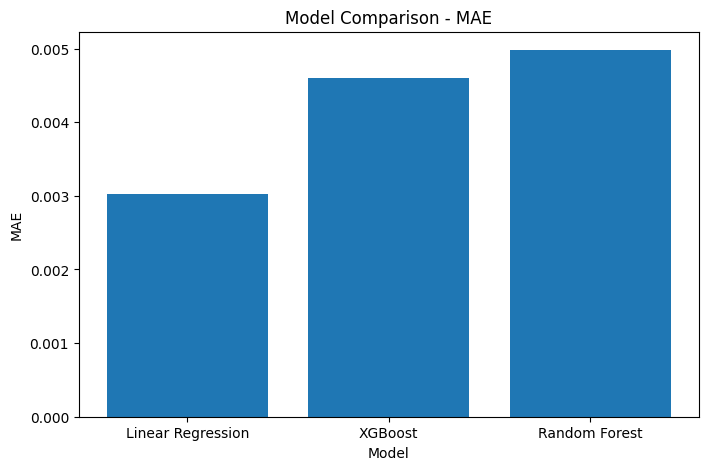

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.show()

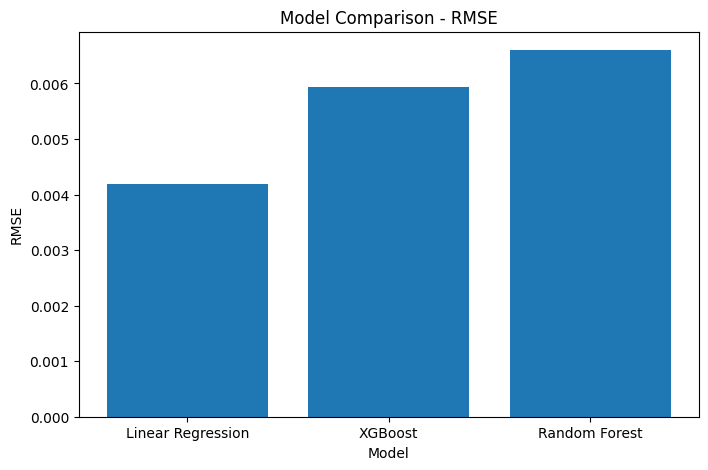

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

--------------------------------------
--------------------------------------

In [ ]:
df.tail()

,Date,Rate,lag_1,lag_7,ma_7,ma_30
645,2026-08-24,1.1664,1.1699,1.1534,1.160786,1.149437
646,2026-08-25,1.1662,1.1664,1.1567,1.162643,1.150237
647,2026-08-26,1.1669,1.1662,1.1593,1.164000,1.151093
648,2026-08-27,1.1645,1.1669,1.1576,1.165086,1.151970
649,2026-08-28,1.1643,1.1645,1.1605,1.166071,1.152563


In [ ]:
latest_features = pd.DataFrame({
    "lag_1": [df["Rate"].iloc[-1]],
    "lag_7": [df["Rate"].iloc[-7]],
    "ma_7": [df["Rate"].iloc[-7:].mean()],
    "ma_30": [df["Rate"].iloc[-30:].mean()]
})

latest_features

,lag_1,lag_7,ma_7,ma_30
0,1.1643,1.1681,1.166614,1.153257


In [ ]:
next_rate_prediction = lr_model.predict(latest_features)
print(
    f"Predicted Next EUR/USD Rate: "
    f"{next_rate_prediction[0]:.6f}"
)

Predicted Next EUR/USD Rate: 1.164332


In [ ]:
last_date = df["Date"].iloc[-1]

print("Last Available Date:", last_date.date())
print("Last Actual EUR/USD Rate:", round(df["Rate"].iloc[-1], 6))

print("\n---------------------------")

print(
    "Predicted Next EUR/USD Rate:",
    round(next_rate_prediction[0], 6)
)

Last Available Date: 2026-08-28
Last Actual EUR/USD Rate: 1.1643

---------------------------
Predicted Next EUR/USD Rate: 1.164332


----------------------------
----------------------------

In [ ]:
joblib.dump(lr_model, "currency_model_eur_usd.pkl")
features = ["lag_1", "lag_7", "ma_7", "ma_30"]

joblib.dump(features, "currency_features.pkl")




loaded_model = joblib.load("currency_model_eur_usd.pkl")

test_prediction = loaded_model.predict(latest_features)

print(test_prediction)

[1.16433229]
